# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

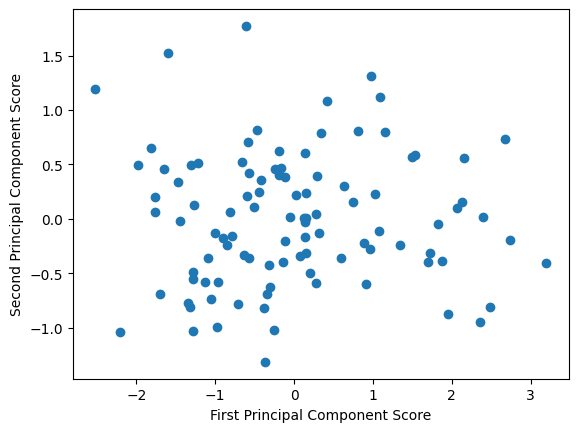

In [7]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

### PCA Graph Analysis

The three outliers in the upper‑left corner have low first principal component (PC1) scores and high second principal component (PC2) scores. A low PC1 score means that all three of their original values—series_1, series_2, and series_3—are low overall, because PC1 represents the direction in which all three series move together. A high PC2 score means that series_3 is higher relative to series_1 and series_2 than usual, because PC2 captures the deviation of series_3 from the tight relationship between series_1 and series_2.

You can confidently say something about series_3 because it has much more noise than series_1 and series_2, so it contributes most of the variation that PC2 captures. You cannot say much about series_1 versus series_2 because they were created to be almost perfectly proportional: series_2 is just series_1 multiplied by a small random factor. Because of this near‑collinearity, PCA cannot separate them, and PC2 does not meaningfully distinguish between them.

A pairplot would show this clearly: series_1 and series_2 form an almost perfect straight line, while series_3 is much more scattered around them.

The advantage of the PCA scatter plot is that it reveals the essential structure of the data: almost all variation lies along one direction (PC1), and the only meaningful secondary variation comes from series_3. It also highlights unusual points, like the three outliers. The disadvantage is that PCA makes it hard to interpret the individual contributions of series_1 and series_2 because they are nearly redundant. Still, the plot does show something interesting: the data are effectively one‑dimensional except for the extra noise in series_3, and the outliers are points where series_3 deviates from the otherwise tight relationship among the variables.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

### Load the Datasets

In [8]:
# Load in the census data

census_data = pd.read_csv("data/census_data.csv", skiprows=1)
census_data

,Geography,Geographic Area Name,Estimate!!Households!!Total,Margin of Error!!Households!!Total,"Estimate!!Households!!Total!!Less than $10,000","Margin of Error!!Households!!Total!!Less than $10,000","Estimate!!Households!!Total!!$10,000 to $14,999","Margin of Error!!Households!!Total!!$10,000 to $14,999","Estimate!!Households!!Total!!$15,000 to $24,999","Margin of Error!!Households!!Total!!$15,000 to $24,999",...,Estimate!!Nonfamily households!!Median income (dollars),Margin of Error!!Nonfamily households!!Median income (dollars),Estimate!!Nonfamily households!!Mean income (dollars),Margin of Error!!Nonfamily households!!Mean income (dollars),Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Household income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Household income in the past 12 months,Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Family income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Family income in the past 12 months,Estimate!!Nonfamily households!!PERCENT ALLOCATED!!Nonfamily income in the past 12 months,Margin of Error!!Nonfamily households!!PERCENT ALLOCATED!!Nonfamily income in the past 12 months
0,8600000US00601,ZCTA5 00601,5555,255,35.6,4.5,16.4,3.1,21,3.4,...,8336,2132,11577,1865,(X),(X),(X),(X),19.1,(X)
1,8600000US00602,ZCTA5 00602,12901,432,28.7,2.9,16.5,2.7,19.4,2.6,...,10612,1584,15425,2636,(X),(X),(X),(X),14.4,(X)
2,8600000US00603,ZCTA5 00603,19431,496,35.9,2.4,12.3,1.6,15.8,1.8,...,9663,803,17658,2637,(X),(X),(X),(X),34.4,(X)
3,8600000US00606,ZCTA5 00606,1983,181,37.2,6.5,12.9,4.1,21.2,5.9,...,12000,2726,13292,2281,(X),(X),(X),(X),15.5,(X)
4,8600000US00610,ZCTA5 00610,8864,348,23.9,3.3,14,2.7,21.4,3.5,...,11448,1959,13972,1809,(X),(X),(X),(X),16,(X)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33115,8600000US99923,ZCTA5 99923,12,17,0,71.2,0,71.2,0,71.2,...,-,**,N,N,(X),(X),(X),(X),0,(X)
33116,8600000US99925,ZCTA5 99925,365,52,9,5.4,1.9,1.3,18.6,5.6,...,21500,1940,46980,17790,(X),(X),(X),(X),10.1,(X)
33117,8600000US99926,ZCTA5 99926,440,42,3.2,1.8,4.8,3.4,10.2,4.7,...,32083,4185,42926,11900,(X),(X),(X),(X),27.2,(X)
33118,8600000US99927,ZCTA5 99927,0,10,-,**,-,**,-,**,...,-,**,-,**,(X),(X),(X),(X),-,(X)


In [9]:
# Load in the Internet data

internet_data = pd.read_csv("data/internet_data.tsv", sep="\t")
internet_data.head()

,ZCTA19,HOUSEHOLDS,N_INTERNET_SUB,N_BROADBAND_ANY_SUB,N_BROADBAND_DSL_CABLE_SUB,N_BROADBAND_SATELLITE_SUB,N_BROADBAND_CELLULAR_SUB,N_INTERNET_NO_SUB,N_NO_INTERNET_ACC,N_COMPUTER_WITH_BROADBAND,...,P_BROADBAND_FIXED_SUB,P_BROADBAND_SATELLITE_SUB,P_BROADBAND_CELLULAR_SUB,P_INTERNET_NO_SUB,P_NO_INTERNET_ACC,P_COMPUTER_WITH_BROADBAND,P_COMPUTER,P_LAPTOP_DESKTOP,P_SMARTPHONE_TABLET,P_NO_COMPUTER
0,601,5509,2974,2921,1245,263,2417,60,2475,2772,...,.2259938269854,.0477400608361,.4387366175652,.0108912689611,.4492648541927,.5031766295433,.5968415141106,.3681248724461,.5269559025764,.4031584560871
1,602,12740,7077,5584,3333,325,3306,466,5197,5217,...,.2616169452667,.0255102049559,.2594976425171,.0365777090192,.4079277813435,.4094976484776,.5858712792397,.406043946743,.5570643544197,.4141287207603
2,603,19228,13222,13161,8264,2363,10155,339,5667,12337,...,.4297899007797,.1228936985135,.528136074543,.0176305379719,.2947264313698,.6416164040565,.7130226492882,.4373829960823,.6614832282066,.2869773209095
3,606,1946,586,581,436,10,160,38,1322,552,...,.2240493297577,.0051387459971,.0822199359536,.0195272359997,.6793422698975,.283658772707,.3884892165661,.3458376228809,.1438848972321,.6115108132362
4,610,8795,5240,4051,2431,146,2408,458,3097,3836,...,.2764070630074,.0166003406048,.2737919390202,.0520750433207,.3521319031715,.436156898737,.6563956737518,.4783399701118,.5956793427467,.3436043262482


In [10]:
# Load in the ecommerce data

ecommerce_data = pd.read_csv("data/ecommerce_data.csv")
ecommerce_data.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1/1/2020,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,1/1/2020,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,1/1/2020,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,1/1/2020,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,1/1/2020,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


### Clean and Filter the Datasets

In [11]:
census_data_filtered = census_data[['Geographic Area Name','Estimate!!Households!!Median income (dollars)']]
census_data_filtered

,Geographic Area Name,Estimate!!Households!!Median income (dollars)
0,ZCTA5 00601,14398
1,ZCTA5 00602,16771
2,ZCTA5 00603,15786
3,ZCTA5 00606,14980
4,ZCTA5 00610,20167
...,...,...
33115,ZCTA5 99923,-
33116,ZCTA5 99925,63125
33117,ZCTA5 99926,58000
33118,ZCTA5 99927,-


In [12]:
# Clean the Zip Code Column so it can be matched
census_data_filtered['Geographic Area Name'] = (
    census_data_filtered['Geographic Area Name']
        .astype(str)
        .str[-5:]
)
census_data_filtered

/tmp/ipykernel_51021/820111520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  census_data_filtered['Geographic Area Name'] = (


,Geographic Area Name,Estimate!!Households!!Median income (dollars)
0,00601,14398
1,00602,16771
2,00603,15786
3,00606,14980
4,00610,20167
...,...,...
33115,99923,-
33116,99925,63125
33117,99926,58000
33118,99927,-


In [13]:
# Rename Column Names to be More Representative and use _ for analysis
census_data_filtered = census_data_filtered.rename(
    columns={'Geographic Area Name': 'Zip_codes'}
)
census_data_filtered

,Zip_codes,Estimate!!Households!!Median income (dollars)
0,00601,14398
1,00602,16771
2,00603,15786
3,00606,14980
4,00610,20167
...,...,...
33115,99923,-
33116,99925,63125
33117,99926,58000
33118,99927,-


In [14]:
# Rename Column Names to be More Representative and use _ for analysis
census_data_filtered = census_data_filtered.rename(
    columns={'Estimate!!Households!!Median income (dollars)': 'Median_household_income'}
)
census_data_filtered

,Zip_codes,Median_household_income
0,00601,14398
1,00602,16771
2,00603,15786
3,00606,14980
4,00610,20167
...,...,...
33115,99923,-
33116,99925,63125
33117,99926,58000
33118,99927,-


In [15]:
# There are some empty values in this column that are represented by - or **, let's take care of those
bad_vals = ["-", "**"]

census_data_cleaned = census_data_filtered[~census_data_filtered['Median_household_income'].isin(bad_vals)]

In [16]:
census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].replace('250,000+', '250000')
census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].replace('2,500-', '2500')

/tmp/ipykernel_51021/4240000029.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].replace('250,000+', '250000')
/tmp/ipykernel_51021/4240000029.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].replace('2,500-', '2500')


In [17]:
# Change Median Household Income column into an int
census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].astype(int)
census_data_cleaned

/tmp/ipykernel_51021/974967686.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  census_data_cleaned['Median_household_income'] = census_data_cleaned['Median_household_income'].astype(int)


,Zip_codes,Median_household_income
0,00601,14398
1,00602,16771
2,00603,15786
3,00606,14980
4,00610,20167
...,...,...
33113,99921,54549
33114,99922,38750
33116,99925,63125
33117,99926,58000


In [18]:
census_data_cleaned['Median_household_income'].dtype

dtype('int64')

In [19]:
# The zip code column should be of type str and not type int
internet_data['ZCTA19'] = internet_data['ZCTA19'].astype(str)

In [20]:
# The zip code column should be of type str and not type int
len_list = []
for row in internet_data['ZCTA19']:
    if len(row) not in len_list:
        len_list.append(len(row))
print(len_list)

[3, 4, 5]


In [21]:
internet_data['ZCTA19'] = internet_data['ZCTA19'].astype(str).str.zfill(5)

In [22]:
# The zip code column should be of type str and not type int
len_list = []
for row in internet_data['ZCTA19']:
    if len(row) not in len_list:
        len_list.append(len(row))
print(len_list)

[5]


In [23]:
# Rename Column Names to be More Representative and use _ for analysis
internet_data_cleaned = internet_data.rename(
    columns={'ZCTA19': 'Zip_codes'}
)
internet_data_cleaned

,Zip_codes,HOUSEHOLDS,N_INTERNET_SUB,N_BROADBAND_ANY_SUB,N_BROADBAND_DSL_CABLE_SUB,N_BROADBAND_SATELLITE_SUB,N_BROADBAND_CELLULAR_SUB,N_INTERNET_NO_SUB,N_NO_INTERNET_ACC,N_COMPUTER_WITH_BROADBAND,...,P_BROADBAND_FIXED_SUB,P_BROADBAND_SATELLITE_SUB,P_BROADBAND_CELLULAR_SUB,P_INTERNET_NO_SUB,P_NO_INTERNET_ACC,P_COMPUTER_WITH_BROADBAND,P_COMPUTER,P_LAPTOP_DESKTOP,P_SMARTPHONE_TABLET,P_NO_COMPUTER
0,00601,5509,2974,2921,1245,263,2417,60,2475,2772,...,.2259938269854,.0477400608361,.4387366175652,.0108912689611,.4492648541927,.5031766295433,.5968415141106,.3681248724461,.5269559025764,.4031584560871
1,00602,12740,7077,5584,3333,325,3306,466,5197,5217,...,.2616169452667,.0255102049559,.2594976425171,.0365777090192,.4079277813435,.4094976484776,.5858712792397,.406043946743,.5570643544197,.4141287207603
2,00603,19228,13222,13161,8264,2363,10155,339,5667,12337,...,.4297899007797,.1228936985135,.528136074543,.0176305379719,.2947264313698,.6416164040565,.7130226492882,.4373829960823,.6614832282066,.2869773209095
3,00606,1946,586,581,436,10,160,38,1322,552,...,.2240493297577,.0051387459971,.0822199359536,.0195272359997,.6793422698975,.283658772707,.3884892165661,.3458376228809,.1438848972321,.6115108132362
4,00610,8795,5240,4051,2431,146,2408,458,3097,3836,...,.2764070630074,.0166003406048,.2737919390202,.0520750433207,.3521319031715,.436156898737,.6563956737518,.4783399701118,.5956793427467,.3436043262482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33115,99923,14,14,14,0,0,14,0,0,14,...,0,0,1,0,0,1,1,1,1,0
33116,99925,317,188,188,64,44,143,1,128,188,...,.2018927484751,.1388012617826,.4511041045189,.0031545741949,.4037854969501,.5930599570274,.8611987233162,.615141928196,.8012618422508,.1388012617826
33117,99926,487,343,343,232,39,317,42,102,339,...,.4763860404491,.0800821334124,.6509240269661,.0862423032522,.2094455808401,.6960985660553,.8993839621544,.6201232075691,.8562628626823,.1006160154939
33118,99927,0,0,0,0,0,0,0,0,0,...,,,,,,,,,,


In [24]:
# Rename Column Names to be More Representative and use _ for analysis
internet_data_cleaned = internet_data_cleaned.rename(
    columns={'HOUSEHOLDS': 'Total_households'}
)
internet_data_cleaned


,Zip_codes,Total_households,N_INTERNET_SUB,N_BROADBAND_ANY_SUB,N_BROADBAND_DSL_CABLE_SUB,N_BROADBAND_SATELLITE_SUB,N_BROADBAND_CELLULAR_SUB,N_INTERNET_NO_SUB,N_NO_INTERNET_ACC,N_COMPUTER_WITH_BROADBAND,...,P_BROADBAND_FIXED_SUB,P_BROADBAND_SATELLITE_SUB,P_BROADBAND_CELLULAR_SUB,P_INTERNET_NO_SUB,P_NO_INTERNET_ACC,P_COMPUTER_WITH_BROADBAND,P_COMPUTER,P_LAPTOP_DESKTOP,P_SMARTPHONE_TABLET,P_NO_COMPUTER
0,00601,5509,2974,2921,1245,263,2417,60,2475,2772,...,.2259938269854,.0477400608361,.4387366175652,.0108912689611,.4492648541927,.5031766295433,.5968415141106,.3681248724461,.5269559025764,.4031584560871
1,00602,12740,7077,5584,3333,325,3306,466,5197,5217,...,.2616169452667,.0255102049559,.2594976425171,.0365777090192,.4079277813435,.4094976484776,.5858712792397,.406043946743,.5570643544197,.4141287207603
2,00603,19228,13222,13161,8264,2363,10155,339,5667,12337,...,.4297899007797,.1228936985135,.528136074543,.0176305379719,.2947264313698,.6416164040565,.7130226492882,.4373829960823,.6614832282066,.2869773209095
3,00606,1946,586,581,436,10,160,38,1322,552,...,.2240493297577,.0051387459971,.0822199359536,.0195272359997,.6793422698975,.283658772707,.3884892165661,.3458376228809,.1438848972321,.6115108132362
4,00610,8795,5240,4051,2431,146,2408,458,3097,3836,...,.2764070630074,.0166003406048,.2737919390202,.0520750433207,.3521319031715,.436156898737,.6563956737518,.4783399701118,.5956793427467,.3436043262482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33115,99923,14,14,14,0,0,14,0,0,14,...,0,0,1,0,0,1,1,1,1,0
33116,99925,317,188,188,64,44,143,1,128,188,...,.2018927484751,.1388012617826,.4511041045189,.0031545741949,.4037854969501,.5930599570274,.8611987233162,.615141928196,.8012618422508,.1388012617826
33117,99926,487,343,343,232,39,317,42,102,339,...,.4763860404491,.0800821334124,.6509240269661,.0862423032522,.2094455808401,.6960985660553,.8993839621544,.6201232075691,.8562628626823,.1006160154939
33118,99927,0,0,0,0,0,0,0,0,0,...,,,,,,,,,,


In [25]:
# Rename Column Names to be More Representative and use _ for analysis
internet_data_cleaned = internet_data_cleaned.rename(
    columns={'N_INTERNET_SUB': 'Households_w_internet_access'}
)
internet_data_cleaned


,Zip_codes,Total_households,Households_w_internet_access,N_BROADBAND_ANY_SUB,N_BROADBAND_DSL_CABLE_SUB,N_BROADBAND_SATELLITE_SUB,N_BROADBAND_CELLULAR_SUB,N_INTERNET_NO_SUB,N_NO_INTERNET_ACC,N_COMPUTER_WITH_BROADBAND,...,P_BROADBAND_FIXED_SUB,P_BROADBAND_SATELLITE_SUB,P_BROADBAND_CELLULAR_SUB,P_INTERNET_NO_SUB,P_NO_INTERNET_ACC,P_COMPUTER_WITH_BROADBAND,P_COMPUTER,P_LAPTOP_DESKTOP,P_SMARTPHONE_TABLET,P_NO_COMPUTER
0,00601,5509,2974,2921,1245,263,2417,60,2475,2772,...,.2259938269854,.0477400608361,.4387366175652,.0108912689611,.4492648541927,.5031766295433,.5968415141106,.3681248724461,.5269559025764,.4031584560871
1,00602,12740,7077,5584,3333,325,3306,466,5197,5217,...,.2616169452667,.0255102049559,.2594976425171,.0365777090192,.4079277813435,.4094976484776,.5858712792397,.406043946743,.5570643544197,.4141287207603
2,00603,19228,13222,13161,8264,2363,10155,339,5667,12337,...,.4297899007797,.1228936985135,.528136074543,.0176305379719,.2947264313698,.6416164040565,.7130226492882,.4373829960823,.6614832282066,.2869773209095
3,00606,1946,586,581,436,10,160,38,1322,552,...,.2240493297577,.0051387459971,.0822199359536,.0195272359997,.6793422698975,.283658772707,.3884892165661,.3458376228809,.1438848972321,.6115108132362
4,00610,8795,5240,4051,2431,146,2408,458,3097,3836,...,.2764070630074,.0166003406048,.2737919390202,.0520750433207,.3521319031715,.436156898737,.6563956737518,.4783399701118,.5956793427467,.3436043262482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33115,99923,14,14,14,0,0,14,0,0,14,...,0,0,1,0,0,1,1,1,1,0
33116,99925,317,188,188,64,44,143,1,128,188,...,.2018927484751,.1388012617826,.4511041045189,.0031545741949,.4037854969501,.5930599570274,.8611987233162,.615141928196,.8012618422508,.1388012617826
33117,99926,487,343,343,232,39,317,42,102,339,...,.4763860404491,.0800821334124,.6509240269661,.0862423032522,.2094455808401,.6960985660553,.8993839621544,.6201232075691,.8562628626823,.1006160154939
33118,99927,0,0,0,0,0,0,0,0,0,...,,,,,,,,,,


In [26]:
# Only selectint the relevant columns from the internet data
internet_data_filtered = internet_data_cleaned[['Zip_codes', 'Total_households', 'Households_w_internet_access']]
internet_data_filtered

,Zip_codes,Total_households,Households_w_internet_access
0,00601,5509,2974
1,00602,12740,7077
2,00603,19228,13222
3,00606,1946,586
4,00610,8795,5240
...,...,...,...
33115,99923,14,14
33116,99925,317,188
33117,99926,487,343
33118,99927,0,0


In [27]:
# Add a column to Show Percentage of Households with Internet Access
internet_data_filtered['Internet_access'] = internet_data_filtered['Households_w_internet_access'] / internet_data_filtered['Total_households']
internet_data_filtered

/tmp/ipykernel_51021/3488362917.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internet_data_filtered['Internet_access'] = internet_data_filtered['Households_w_internet_access'] / internet_data_filtered['Total_households']


,Zip_codes,Total_households,Households_w_internet_access,Internet_access
0,00601,5509,2974,0.539844
1,00602,12740,7077,0.555495
2,00603,19228,13222,0.687643
3,00606,1946,586,0.301131
4,00610,8795,5240,0.595793
...,...,...,...,...
33115,99923,14,14,1.000000
33116,99925,317,188,0.593060
33117,99926,487,343,0.704312
33118,99927,0,0,NaN


In [28]:
# Drop the null values
internet_data_filtered = internet_data_filtered.dropna()

In [29]:
# Switching the Postal Code to be a string data type
ecommerce_data['Postal Code'] = ecommerce_data['Postal Code'].astype('string')
ecommerce_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   string 
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null 

In [30]:
# Ensure 5-character postal codes with leading zeros
ecommerce_data["Postal Code"] = ecommerce_data["Postal Code"].astype(str).str.zfill(5)

In [31]:
# Group ecommerce data by postal code
ecommerce_data_filtered = ecommerce_data.groupby('Postal Code').size().reset_index(name="order_count")
ecommerce_data_filtered

,Postal Code,order_count
0,01841,12
1,01852,7
2,02038,2
3,02138,2
4,02149,9
...,...,...
432,98502,2
433,98632,2
434,98661,1
435,99207,4


In [32]:
# Rename Column Names to be More Representative and use _ for analysis
ecommerce_data_filtered = ecommerce_data_filtered.rename(
    columns={'Postal Code': 'Zip_codes'}
)
ecommerce_data_filtered


,Zip_codes,order_count
0,01841,12
1,01852,7
2,02038,2
3,02138,2
4,02149,9
...,...,...
432,98502,2
433,98632,2
434,98661,1
435,99207,4


### Merge the Dfs

In [33]:
merged_df = (
    census_data_filtered
    .merge(internet_data_filtered, on='Zip_codes', how='inner')
    .merge(ecommerce_data_filtered, on='Zip_codes', how='inner')
)
merged_df

,Zip_codes,Median_household_income,Total_households,Households_w_internet_access,Internet_access,order_count
0,01841,45486,15149,10693,0.705855,12
1,01852,65445,14255,10844,0.760716,7
2,02038,118193,11941,11205,0.938364,2
3,02138,104641,14188,12513,0.881942,2
4,02149,70627,16021,13483,0.841583,9
...,...,...,...,...,...,...
432,98502,74031,14290,12469,0.872568,2
433,98632,51188,20963,17051,0.813385,2
434,98661,59466,18797,16371,0.870937,1
435,99207,42913,12204,10541,0.863733,4


In [34]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Zip_codes                     437 non-null    object 
 1   Median_household_income       437 non-null    object 
 2   Total_households              437 non-null    int64  
 3   Households_w_internet_access  437 non-null    int64  
 4   Internet_access               437 non-null    float64
 5   order_count                   437 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 20.6+ KB


In [35]:
# Change Median Household Income column into an int
merged_df['Median_household_income'] = merged_df['Median_household_income'].astype(int)
merged_df

,Zip_codes,Median_household_income,Total_households,Households_w_internet_access,Internet_access,order_count
0,01841,45486,15149,10693,0.705855,12
1,01852,65445,14255,10844,0.760716,7
2,02038,118193,11941,11205,0.938364,2
3,02138,104641,14188,12513,0.881942,2
4,02149,70627,16021,13483,0.841583,9
...,...,...,...,...,...,...
432,98502,74031,14290,12469,0.872568,2
433,98632,51188,20963,17051,0.813385,2
434,98661,59466,18797,16371,0.870937,1
435,99207,42913,12204,10541,0.863733,4


In [36]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Zip_codes                     437 non-null    object 
 1   Median_household_income       437 non-null    int64  
 2   Total_households              437 non-null    int64  
 3   Households_w_internet_access  437 non-null    int64  
 4   Internet_access               437 non-null    float64
 5   order_count                   437 non-null    int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 20.6+ KB


### Plot a Heatmap of the Relationships between Median Household Income, Internet acess (%), and Order Count

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Copy your merged dataframe
df = merged_df.copy()

# Define ordered labels
labels = ['low', 'medium', 'high']
cat_type = pd.CategoricalDtype(categories=labels, ordered=True)

# Create quantile-based categories
df['income_cat'] = pd.qcut(df['Median_household_income'], q=3, labels=labels).astype(cat_type)
df['internet_cat'] = pd.qcut(df['Internet_access'], q=3, labels=labels).astype(cat_type)
df['order_cat'] = pd.qcut(df['order_count'], q=3, labels=labels).astype(cat_type)


/tmp/ipykernel_51021/781136672.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df.pivot_table(
/tmp/ipykernel_51021/781136672.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(
/tmp/ipykernel_51021/781136672.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(
/tmp/ipykernel_51021/781136672.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify o

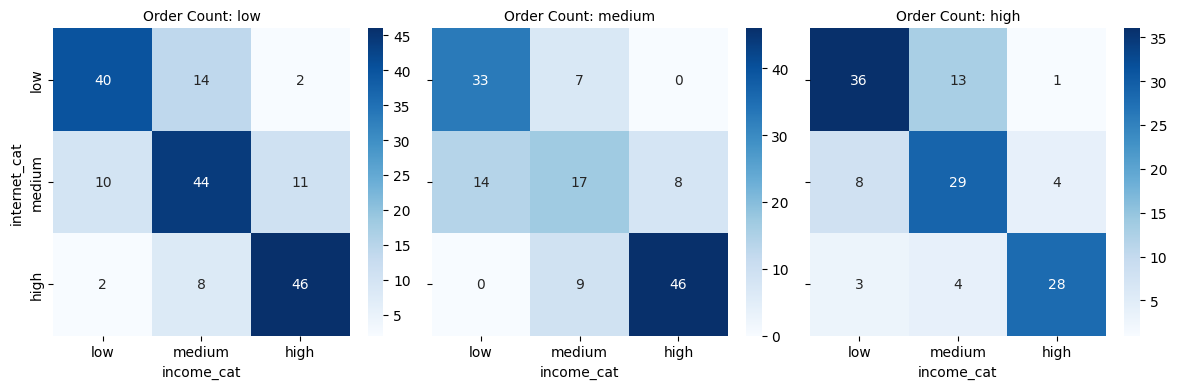

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Build a pivot table for each order category
pivot_data = df.pivot_table(
    index='internet_cat',
    columns='income_cat',
    values='order_count',
    aggfunc='count'
)

# Create a FacetGrid: one heatmap per order_cat
g = sns.FacetGrid(df, col='order_cat', col_wrap=3, height=4)

def heatmap(data, **kwargs):
    pivot = data.pivot_table(
        index='internet_cat',
        columns='income_cat',
        values='order_count',
        aggfunc='count'
    )
    sns.heatmap(pivot, cmap='Blues', annot=True, fmt='g')

g.map_dataframe(heatmap)
g.set_titles(col_template="Order Count: {col_name}")
plt.show()



In [39]:
labels = ['low', 'medium', 'high']
cat_type = pd.CategoricalDtype(categories=labels, ordered=True)

df_copy = df.copy()

df_copy['income_cat'] = pd.qcut(df_copy['Median_household_income'], q=3, labels=labels).astype(cat_type)
df_copy['internet_cat'] = pd.qcut(df_copy['Internet_access'], q=3, labels=labels).astype(cat_type)

# order_count may need duplicates='drop' if not enough unique values
df_copy['order_cat'] = pd.qcut(df_copy['order_count'], q=3, labels=labels, duplicates='drop').astype(cat_type)


In [40]:
pivot = df_copy.pivot_table(
    index='income_cat',
    columns='internet_cat',
    values='order_count',
    aggfunc='sum'
)
pivot


/tmp/ipykernel_51021/2729385079.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_copy.pivot_table(


internet_cat,low,medium,high
income_cat,,,
low,976,159,56
medium,242,528,181
high,10,129,1031


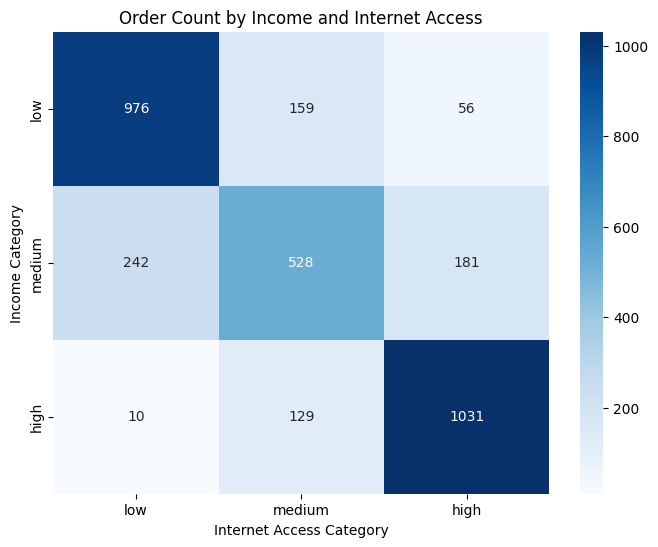

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
ax = sns.heatmap(pivot, cmap="Blues", annot=True, fmt='g')

ax.set_title("Order Count by Income and Internet Access")
ax.set_xlabel("Internet Access Category")
ax.set_ylabel("Income Category")

plt.show()


The heat map reveals a strikingly uneven relationship between income, internet access, and order activity across ZIP codes. Order counts are highest at the extremes: low‑income areas with low internet access show unexpectedly heavy ordering, while high‑income areas with high internet access also generate substantial order volume. This creates a U‑shaped pattern, suggesting two distinct customer bases driving demand. In contrast, middle‑income groups display more moderate and evenly distributed order counts, regardless of internet access level. The pattern also shows that internet access alone does not predict ordering behavior; instead, it interacts with income in ways that highlight different types of consumer engagement. Overall, the heat map suggests that both resource‑constrained households and affluent households are strong contributors to order activity, though likely for very different underlying reasons.

### Bubble Plots

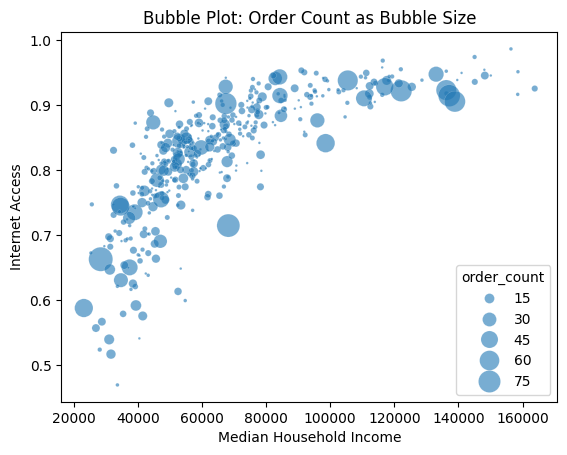

In [42]:
min_order = df['order_count'].min()
max_order = df['order_count'].max()
maxbubble = 300

ax = sns.scatterplot(
    data=df,
    x='Median_household_income',
    y='Internet_access',
    size='order_count',
    sizes=(min_order / max_order * maxbubble, maxbubble),
    alpha=0.6
)

ax.set_title("Bubble Plot: Order Count as Bubble Size")
ax.set_xlabel("Median Household Income")
ax.set_ylabel("Internet Access")
plt.show()


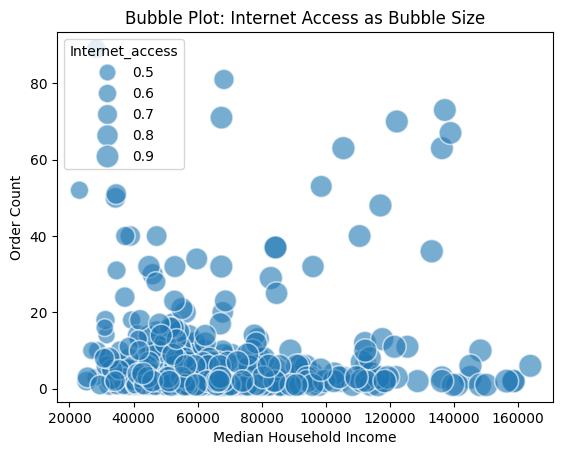

In [43]:
min_internet = df['Internet_access'].min()
max_internet = df['Internet_access'].max()

ax = sns.scatterplot(
    data=df,
    x='Median_household_income',
    y='order_count',
    size='Internet_access',
    sizes=(min_internet / max_internet * maxbubble, maxbubble),
    alpha=0.6
)

ax.set_title("Bubble Plot: Internet Access as Bubble Size")
ax.set_xlabel("Median Household Income")
ax.set_ylabel("Order Count")
plt.show()


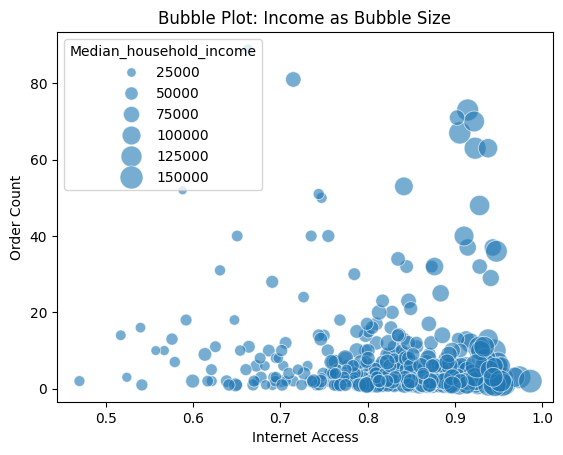

In [44]:
min_income = df['Median_household_income'].min()
max_income = df['Median_household_income'].max()

ax = sns.scatterplot(
    data=df,
    x='Internet_access',
    y='order_count',
    size='Median_household_income',
    sizes=(min_income / max_income * maxbubble, maxbubble),
    alpha=0.6
)

ax.set_title("Bubble Plot: Income as Bubble Size")
ax.set_xlabel("Internet Access")
ax.set_ylabel("Order Count")
plt.show()


Across the three bubble plots, a consistent socioeconomic pattern emerges: income, internet access, and order activity are tightly interwoven, but not always in a linear or predictable way. In the first plot, where bubble size reflects order count, higher‑income ZIP codes with strong internet access tend to produce larger bubbles, suggesting that affluence and digital connectivity reinforce one another in driving consumer activity. The second plot flips the perspective by using internet access as the bubble size, and it becomes clear that areas with higher connectivity often show higher order counts even when income varies, indicating that access itself may be a key enabling factor for online engagement. The third plot, which uses income as the bubble size, reinforces this idea: larger bubbles cluster toward the upper‑right region, where both internet access and order count are high. Taken together, the three visualizations show that while income and internet access each independently relate to order behavior, their combined effect is especially strong. High‑income, high‑access ZIP codes consistently dominate order activity, but the plots also hint at pockets of lower‑income areas with meaningful engagement, suggesting that consumer behavior is shaped by a blend of economic capacity and digital opportunity rather than a single determinant.

In [45]:
from sklearn.decomposition import PCA
import pandas as pd

# Select only the three numeric columns
X = df[['Median_household_income', 'Internet_access', 'order_count']]

# Standard PCA with 3 components
pca = PCA(n_components=3)
pca.fit(X)

print("Explained variance ratios:", pca.explained_variance_ratio_)
print("Component vectors:\n", pca.components_)


Explained variance ratios: [9.99999788e-01 2.11731221e-07 4.96380798e-12]
Component vectors:
 [[ 9.99999999e-01  2.47543420e-06  3.40268223e-05]
 [-3.40249606e-05 -7.48233925e-04  9.99999719e-01]
 [-2.50089353e-06  9.99999720e-01  7.48233840e-04]]


In [46]:
from sklearn import decomposition

# Select only the three variables you want to analyze
df3 = df[['Median_household_income', 'Internet_access', 'order_count']]

# Run PCA with 3 components
pca3 = decomposition.PCA(n_components=3)
pca3.fit(df3)

# Print explained variance and component vectors
print("Explained variance ratios:")
print(pca3.explained_variance_ratio_)

print("\nComponent vectors (PC1, PC2, PC3):")
print(pca3.components_)


Explained variance ratios:
[9.99999788e-01 2.11731221e-07 4.96380798e-12]

Component vectors (PC1, PC2, PC3):
[[ 9.99999999e-01  2.47543420e-06  3.40268223e-05]
 [-3.40249606e-05 -7.48233925e-04  9.99999719e-01]
 [-2.50089353e-06  9.99999720e-01  7.48233840e-04]]


The PCA results indicate that almost all of the variation in the dataset is captured by the first principal component, which explains essentially 100% of the total variance. This means the three variables—median household income, internet access, and order count—change together in a way that is nearly perfectly aligned along a single direction. The first component points almost entirely along the income axis, showing that income dominates the overall structure of the data. The second component aligns almost exactly with order count, and the third aligns with internet access, but both explain only tiny amounts of additional variation. In practical terms, the dataset behaves as if it were one‑dimensional: income accounts for nearly all meaningful differences between observations, while the other two variables contribute only very small adjustments around that main trend.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

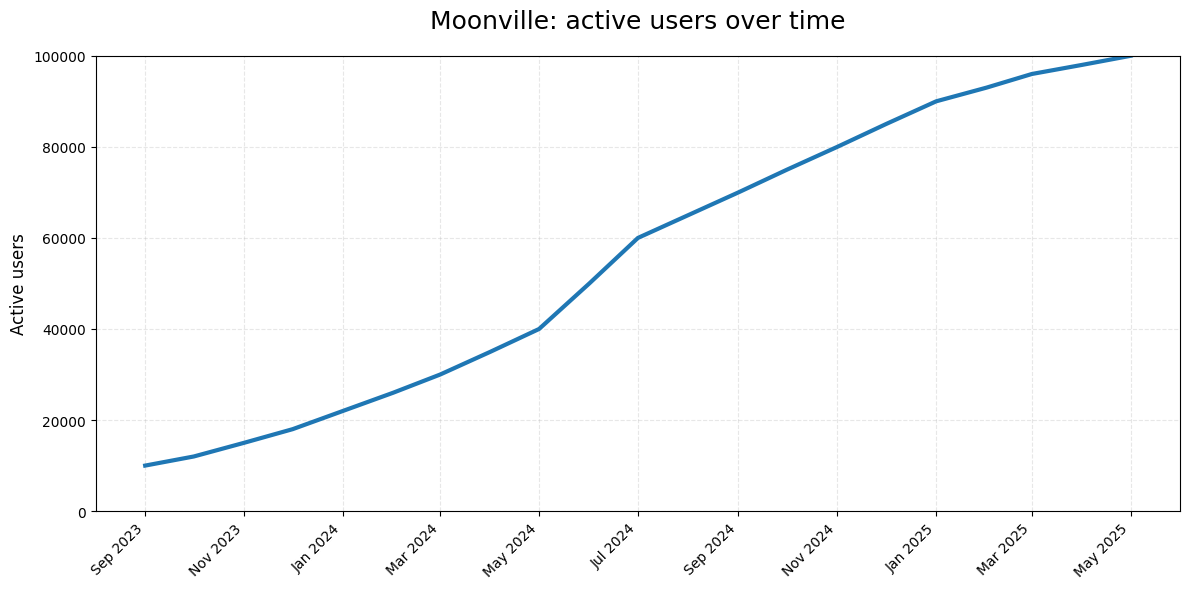

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Correct date range: Sep 2023 to May 2025 (inclusive)
dates = pd.date_range(start="2023-09-01", end="2025-05-01", freq="MS")
len(dates)  # should be 21

active_users = [
    10000, 12000, 15000, 18000, 22000, 26000, 30000,
    35000, 40000, 50000, 60000, 65000, 70000, 75000,
    80000, 85000, 90000, 93000, 96000, 98000, 100000
]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(dates, active_users, color="#1f77b4", linewidth=3)

# Title
ax.set_title("Moonville: active users over time", fontsize=18, pad=20)

# Y-axis
ax.set_ylabel("Active users", fontsize=12)
ax.set_ylim(0, 100000)

# X-axis formatting
ax.set_xticks(dates[::2])  # every 2 months
ax.set_xticklabels([d.strftime("%b %Y") for d in dates[::2]],
                   rotation=45, ha="right")

# Grid
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()
